In [2]:
import os
import numpy as np
import rasterio
from rasterio import warp
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

# Function to scale the data to 0-255 range
def scale_data(data):
    min_value, max_value = np.percentile(data, [2, 98])
    scaled_data = (data - min_value) / (max_value - min_value) * 255
    scaled_data = np.clip(scaled_data, 0, 255)
    return scaled_data.astype(np.uint8)

# Function to convert data to decibel units and stretch within fixed thresholds
def convert_to_db_and_stretch(data, lower_threshold, upper_threshold):
    data_db = 10 * np.log10(data)
    data_db = (data_db - lower_threshold) / (upper_threshold - lower_threshold) * 255
    data_db = np.clip(data_db, 0, 255)
    return data_db.astype(np.uint8)

# Function to generate the mask library based on dB image and threshold values
def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-7, -2]  # Ice Free threshold
    threshold_ice_bergs = [-2, 3.5]  # Ice Covered threshold
    threshold_multiyearice = [-1, 3.5]  # Multi-Year Ice threshold
    threshold_firstyearice = [-2, -1]  # First-Year Ice threshold

    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
    }

    return mask_lib


# Function to resize the HV image to match the dimensions of the HH image
def resize_hv_data(hv_data, hv_transform, hh_transform, hh_shape):
    hv_data_resized = np.empty(hh_shape, dtype=hv_data.dtype)
    warp.reproject(
        source=hv_data,
        destination=hv_data_resized,
        src_transform=hv_transform,
        src_crs=hv_ds.crs,
        dst_transform=hh_transform,
        dst_crs=hh_ds.crs,
        resampling=Resampling.nearest
    )
    return hv_data_resized

# List the HH and HV file paths in the respective folders
hh_folder = 'd:/ISRO/Proj/HH_tiles'
hv_folder = 'd:/ISRO/Proj/HV_tiles'
output_folder = 'd:/ISRO/Proj/working/input'
os.makedirs(output_folder, exist_ok=True)

hh_files = os.listdir(hh_folder)
hv_files = os.listdir(hv_folder)

# Iterate over the files and process each pair of HH and HV images
for hh_file, hv_file in zip(hh_files, hv_files):
    hh_tif_file = os.path.join(hh_folder, hh_file)
    hv_tif_file = os.path.join(hv_folder, hv_file)

    with rasterio.open(hh_tif_file) as hh_ds:
        hh_data = hh_ds.read(1)

    with rasterio.open(hv_tif_file) as hv_ds:
        hv_data = hv_ds.read(1)
        hv_transform = hv_ds.transform

        # Resize the HV image to match the dimensions of the HH image
        hh_transform = hh_ds.transform
        hv_data_resized = resize_hv_data(hv_data, hv_transform, hh_transform, hh_data.shape)

    # Set zero and negative values in hv_data_resized to a small positive value to avoid warnings
    hv_data_resized[hv_data_resized <= 0] = 1e-9

    # Calculate the HH / HV ratio and HH - HV difference
    hh_hv_ratio = hh_data / hv_data_resized
    hh_hv_diff = hh_data - hv_data_resized

    # Convert the data to dB units using the 'convert_to_db_and_stretch' function
    hh_hv_ratio_db = convert_to_db_and_stretch(hh_hv_ratio, -7, 3.5)
    hh_hv_diff_db = convert_to_db_and_stretch(hh_hv_diff, -7, 3.5)
    hv = convert_to_db_and_stretch(hv_data_resized, -7, 3.5)

    # Create gray-scale composite by combining the processed HH-HV ratio and HH-HV difference
    gray_composite = 0.33*hv + 0.33 * hh_hv_ratio_db + 0.33 * hh_hv_diff_db #for just composite of two

    # Save the gray-scale composite as a TIFF file
    output_tif_file = os.path.join('d:/ISRO/Proj/working/input', hh_file.replace('.tif', '_gray_composite.tif'))

    with rasterio.open(output_tif_file, 'w', driver='GTiff', width=hh_ds.width, height=hh_ds.height, count=1, dtype=gray_composite.dtype) as dst:
        dst.write(gray_composite, 1)

    print(f"Gray-scale composite image saved as {output_tif_file}")

/tmp/ipykernel_33/968916971.py:17: RuntimeWarning: invalid value encountered in log10
  data_db = 10 * np.log10(data)
/opt/conda/lib/python3.10/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Gray-scale composite image saved as /kaggle/working/input/2354586151_SIGMANAUGHT_L2A_ORBIT-4399-LEVEL-STD-MODE-MRSHH_gray_composite.tif


/tmp/ipykernel_33/968916971.py:17: RuntimeWarning: invalid value encountered in log10
  data_db = 10 * np.log10(data)
/opt/conda/lib/python3.10/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Gray-scale composite image saved as /kaggle/working/input/2354586141_SIGMANAUGHT_L2A_ORBIT-4399-LEVEL-STD-MODE-MRSHH_gray_composite.tif


/tmp/ipykernel_33/968916971.py:17: RuntimeWarning: invalid value encountered in log10
  data_db = 10 * np.log10(data)
/opt/conda/lib/python3.10/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


...

Gray-scale composite image saved as /kaggle/working/input/2354586181_SIGMANAUGHT_L2A_ORBIT-4273-LEVEL-STD-MODE-MRSHH_gray_composite.tif


/tmp/ipykernel_33/968916971.py:17: RuntimeWarning: invalid value encountered in log10
  data_db = 10 * np.log10(data)
/opt/conda/lib/python3.10/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Gray-scale composite image saved as /kaggle/working/input/235458671_SIGMANAUGHT_L2A_ORBIT-5699-LEVEL-STD-MODE-MRS-POL-HH_gray_composite.tif


/tmp/ipykernel_33/968916971.py:17: RuntimeWarning: invalid value encountered in log10
  data_db = 10 * np.log10(data)
/opt/conda/lib/python3.10/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Gray-scale composite image saved as /kaggle/working/input/235458611_SIGMANAUGHT_L2A_ORBIT-6228-LEVEL-STD-MODE-MRS-POL-HH_gray_composite.tif


In [3]:
# pip install tifffile


In [4]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img, ImageDataGenerator
from PIL import Image 
import warnings
import tifffile as tiff
warnings.filterwarnings("ignore")

import os
from tifffile import imread

# set the necessary directories
# img_dir = '/kaggle/input/sar-images'
img_dir = 'd:/ISRO/Proj/working/input'

img_filenames = os.listdir(img_dir)
img_names = [s.split('.')[0] for s in img_filenames if s.endswith('.tif')]

img_ext = '.tif'

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

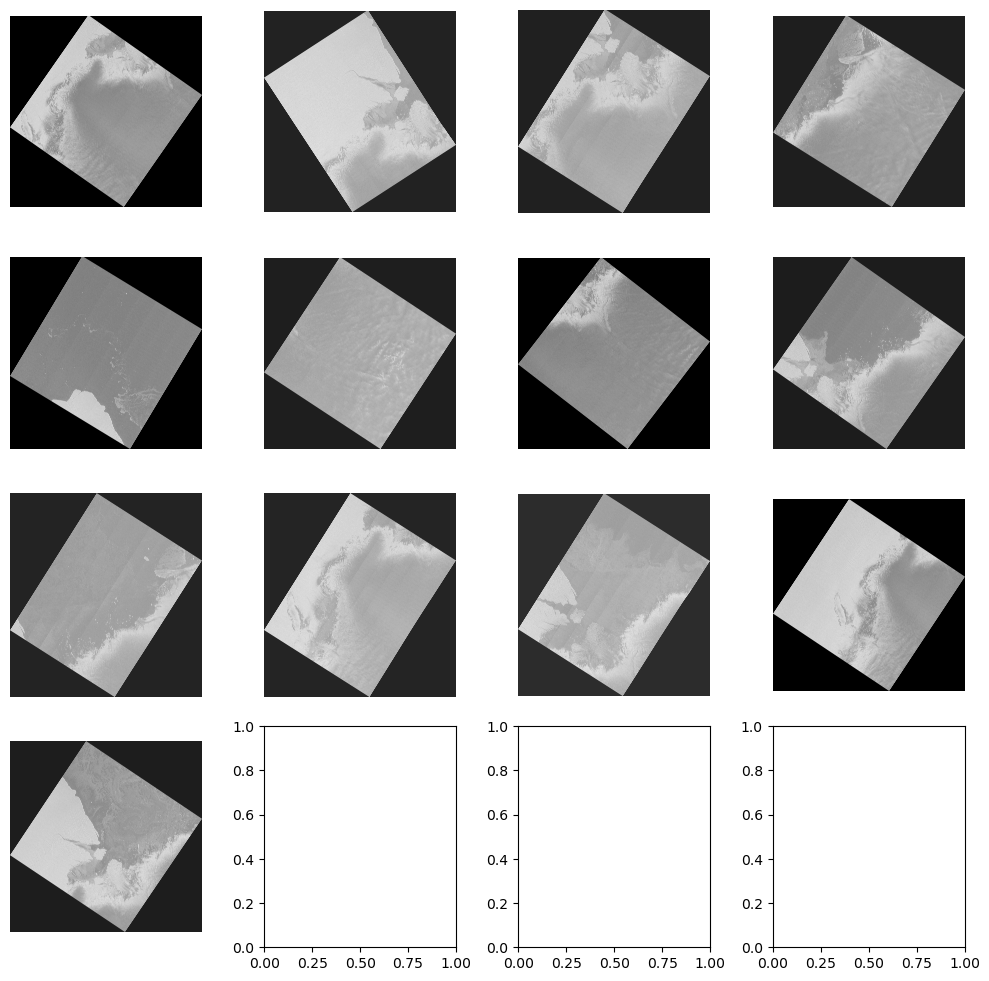

In [5]:
import os
import matplotlib.pyplot as plt
import tifffile as tiff

# Set the folder path containing the images
folder_path = "d:/ISRO/Proj/HV_tiles"

# Get a list of files in the folder
file_list = os.listdir(folder_path)

# Create a subplot grid to display the images
num_images = len(file_list)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Iterate over each file in the folder
for i, file_name in enumerate(file_list):
    # Check if the file is an image (TIFF format)
    if file_name.lower().endswith('.tif') or file_name.lower().endswith('.tif'):
        # Get the directory path of the image file
        file_path = os.path.join(folder_path, file_name)
        
        # Load and display the image using tifffile
        image = tiff.imread(file_path)
        
        # Determine the subplot indices
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Display the image in the corresponding subplot
        axes[row_idx, col_idx].imshow(image, cmap='gray')
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

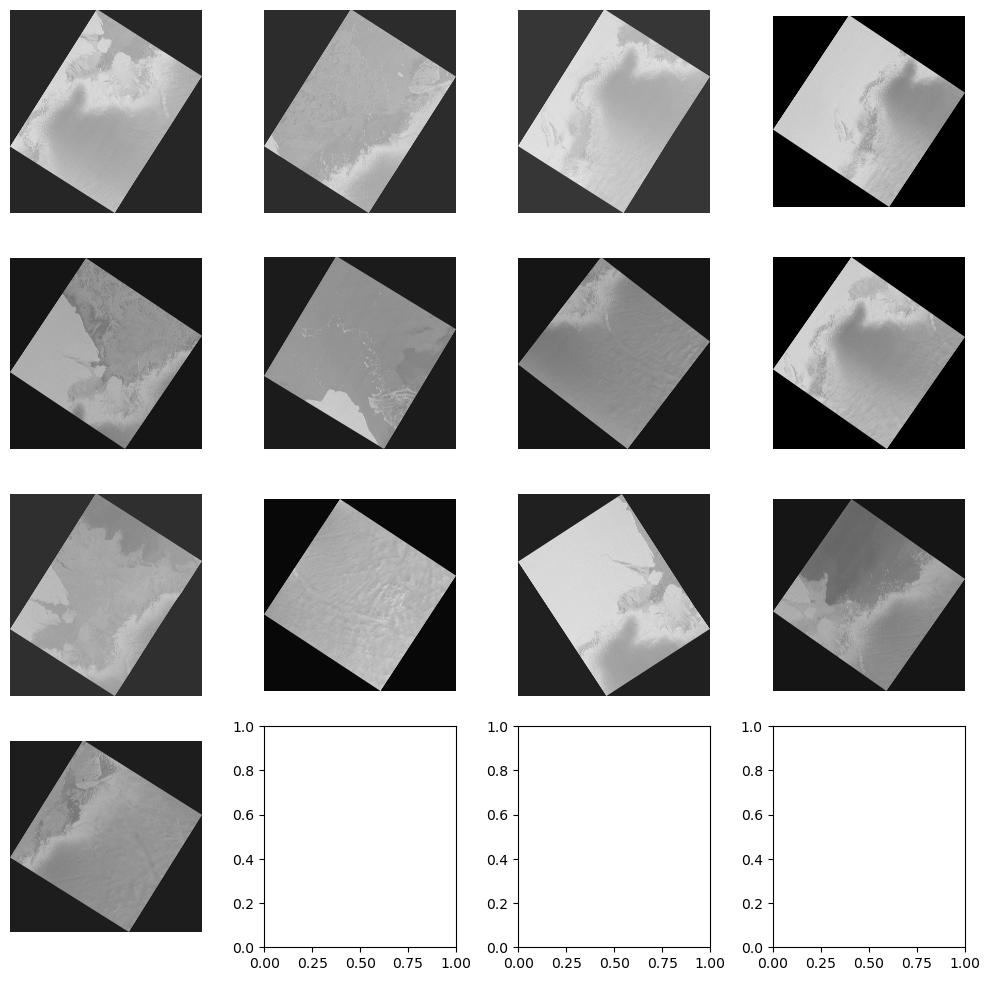

In [6]:
import os
import matplotlib.pyplot as plt
import tifffile as tiff

# Set the folder path containing the images
folder_path = "d:/ISRO/Proj/HH_tiles"

# Get a list of files in the folder
file_list = os.listdir(folder_path)

# Create a subplot grid to display the images
num_images = len(file_list)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Iterate over each file in the folder
for i, file_name in enumerate(file_list):
    # Check if the file is an image (TIFF format)
    if file_name.lower().endswith('.tif') or file_name.lower().endswith('.tif'):
        # Get the directory path of the image file
        file_path = os.path.join(folder_path, file_name)
        
        # Load and display the image using tifffile
        image = tiff.imread(file_path)
        
        # Determine the subplot indices
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Display the image in the corresponding subplot
        axes[row_idx, col_idx].imshow(image, cmap='gray')
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

In [7]:
import os
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np

# Set the folder path containing the images
folder_path = "d:/ISRO/Proj/working/input"

# Get a list of files in the folder
file_list = os.listdir(folder_path)

# Create a subplot grid to display the images
num_images = len(file_list)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Iterate over each file in the folder
for i, file_name in enumerate(file_list):
    # Check if the file is a TIF image
    if file_name.endswith('.tif'):
        # Get the directory path of the TIF file
        file_path = os.path.join(folder_path, file_name)
        
        # Load and display the TIF image
        image = tiff.imread(file_path)
        
        # Determine the subplot indices
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Display the image in the corresponding subplot
        axes[row_idx, col_idx].imshow(image, cmap='gray')
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


Exception ignored in: <function _xla_gc_callback at 0x7d598df9e320>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/jax/_src/lib/__init__.py", line 103, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d59bbdbf520> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d59bbdbe830> (for post_execute):


KeyboardInterrupt: 

In [ ]:
# pip install scikit-image


In [ ]:
#no need for composite image data set as already normalization is  being done!!!
import numpy as np
import cv2
import os

# Function to perform Min-Max normalization
def normalize_backscattering(data):
    min_value = np.min(data)
    max_value = np.max(data)
    normalized_data = 255 * (data - min_value) / (max_value - min_value)
    normalized_data = normalized_data.astype(np.uint8)
    return normalized_data

# Folder path containing the TIFF files
folder_path = 'd:/ISRO/Proj/HV_tiles'  # Replace this with the actual path to your folder

# Output folder for the normalized TIFF files
norm_folder = 'd:/ISRO/Proj/working/norm_data'  # Replace this with the desired output path

# Check if the folder exists
if not os.path.exists(folder_path):
    print(f"Folder not found: {folder_path}")
else:
    # Create the output folder if it doesn't exist
    if not os.path.exists(norm_folder):
        os.makedirs(norm_folder)

    # Loop through each TIFF file in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.tiff') or filename.endswith('.tif'):
            # Read the TIFF file
            file_path = os.path.join(folder_path, filename)
            backscattering_data = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

            # Perform Min-Max normalization
            normalized_data = normalize_backscattering(backscattering_data)

            # Print the minimum and maximum values in the normalized backscattering data
            min_value = np.min(normalized_data)
            max_value = np.max(normalized_data)
            print(f"File: {filename}")
            print("Minimum value:", min_value)
            print("Maximum value:", max_value)
            print("\n")

            # Save the normalized data as a new TIFF file
            new_filename = "normalized_" + filename
            new_file_path = os.path.join(norm_folder, new_filename)
            cv2.imwrite(new_file_path, normalized_data)

print("Normalization and saving complete!")


In [ ]:
#just for HV images

import numpy as np
import tifffile as tiff
from skimage.transform import resize
import os
from PIL import Image
import matplotlib.pyplot as plt

def convert_to_db(image):
    with np.errstate(divide='ignore', invalid='ignore'):
        db_image = 10 * np.log10(image)
    db_image[np.isinf(db_image)] = np.nan
    return db_image

def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-7,-2]  # Ice Free threshold
    threshold_ice_bergs = [-1.5,-1]  # Ice Covered threshold
    threshold_multiyearice = [-1, 3.5]  # Multi-Year Ice threshold
    threshold_firstyearice = [-2, -1.5]  # First-Year Ice threshold


    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])
    #mask_icetype4 = (db_image >= threshold_icetype4[0]) & (db_image <= threshold_icetype4[1])
    #mask_newice = (db_image >= threshold_newice[0]) & (db_image <= threshold_newice[1])

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
        #'Ice Type 4': mask_icetype4.astype(int),
        #'New Ice': mask_newice.astype(int)
    }

    return mask_lib

# Folder path containing the SAR images
folder_path = "d:/ISRO/Proj/working/norm_data"
folder_path2 = "/kaggle/input/images-mask20"
output_folder = "d:/ISRO/Proj/working/output"

# Initialize the dictionaries to store the percentages for each ice type
total_percentages = {ice_type: 0 for ice_type in ['Ice Free', 'Ice Covered', 'Multi-Year Ice', 'First-Year Ice']}
label_to_int = {'Ice Free': 0, 'Ice bergs': 16, 'Multi-Year Ice': 64, 'First-Year Ice': 128}

num_images = 0
y = []
x = []
z = []

# Check if the output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Iterate through the images in the folder
for image_file in os.listdir(folder_path):
    if image_file.endswith(".tif"):
        image_path = os.path.join(folder_path, image_file)
        mask_path = os.path.join(folder_path2, image_file)

        # Load and preprocess the SAR image
        image = tiff.imread(image_path)
        image = resize(image, (256, 256))
        db_image = convert_to_db(image)
        
            # Print the maximum and minimum values of the dB image
        print(f"Image: {image_file}")
        print("Max dB value:", np.nanmax(db_image))
        print("Min dB value:", np.nanmin(db_image))

        # Generate the mask library for the dB image
        mask_lib = generate_mask_lib(db_image)

        # Save the mask images to the output folder
        for ice_type, mask_image in mask_lib.items():
            output_path = os.path.join(output_folder, image_file.replace(".tif", f"_{ice_type}_mask.png"))
            mask_image = (mask_image * 255).astype(np.uint8)
            tiff.imsave(output_path, mask_image)

            # Display the mask image
            plt.imshow(mask_image, cmap='gray')
            plt.axis('off')
            plt.title(ice_type)
            plt.show()


In [ ]:
#for composite images

import numpy as np
import tifffile as tiff
from skimage.transform import resize
import os
from PIL import Image
import matplotlib.pyplot as plt

def convert_to_db(image):
    with np.errstate(divide='ignore', invalid='ignore'):
        db_image = 10 * np.log10(image)
    db_image[np.isinf(db_image)] = np.nan
    return db_image

def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-np.inf,-35]  # Ice Free threshold
    threshold_ice_bergs = [-25,-15]  # Ice Covered threshold
    threshold_multiyearice = [-15, np.inf]  # Multi-Year Ice threshold
    threshold_firstyearice = [-35, -25]  # First-Year Ice threshold


    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])
    #mask_icetype4 = (db_image >= threshold_icetype4[0]) & (db_image <= threshold_icetype4[1])
    #mask_newice = (db_image >= threshold_newice[0]) & (db_image <= threshold_newice[1])

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
        #'Ice Type 4': mask_icetype4.astype(int),
        #'New Ice': mask_newice.astype(int)
    }

    return mask_lib

# Folder path containing the SAR images
folder_path = "d:/ISRO/Proj/working/input"
folder_path2 = "/kaggle/input/images-mask20"
output_folder = "d:/ISRO/Proj/working/output"

# Initialize the dictionaries to store the percentages for each ice type
total_percentages = {ice_type: 0 for ice_type in ['Ice Free', 'Ice Covered', 'Multi-Year Ice', 'First-Year Ice']}
label_to_int = {'Ice Free': 0, 'Ice bergs': 2, 'Multi-Year Ice': 3, 'First-Year Ice': 1}

num_images = 0
y = []
x = []
z = []

# Check if the output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Iterate through the images in the folder
for image_file in os.listdir(folder_path):
    if image_file.endswith(".tif"):
        image_path = os.path.join(folder_path, image_file)
        mask_path = os.path.join(folder_path2, image_file)

        # Load and preprocess the SAR image
        image = tiff.imread(image_path)
        image = resize(image, (256, 256))
        db_image = convert_to_db(image)
        
            # Print the maximum and minimum values of the dB image
        print(f"Image: {image_file}")
        print("Max dB value:", np.nanmax(db_image))
        print("Min dB value:", np.nanmin(db_image))

        # Generate the mask library for the dB image
        mask_lib = generate_mask_lib(db_image)

        # Save the mask images to the output folder
        for ice_type, mask_image in mask_lib.items():
            output_path = os.path.join(output_folder, image_file.replace(".tif", f"_{ice_type}_mask.png"))
            mask_image = (mask_image * 255).astype(np.uint8)
            tiff.imsave(output_path, mask_image)

            # Display the mask image
            plt.imshow(mask_image, cmap='gray')
            plt.axis('off')
            plt.title(ice_type)
            plt.show()


In [ ]:
# pip install pillow


In [ ]:
import os

# Folder path containing the TIF images
folder_path = "d:/ISRO/Proj/working/input"

# Get the list of image names in the folder
image_names = [filename for filename in os.listdir(folder_path) if filename.endswith(".tif")]

# Print the names of the images
for image_name in image_names:
    print(image_name)


In [ ]:
#for HV images

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
import os
import shutil
import tifffile as tiff
import matplotlib.pyplot as plt

def convert_to_db(image):
    with np.errstate(divide='ignore', invalid='ignore'):
        db_image = 10 * np.log10(image)
    return db_image

def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-7, -2]  # Ice Free threshold
    threshold_ice_bergs = [-2, 3.5]  # Ice Covered threshold
    threshold_multiyearice = [-1, 3.5]  # Multi-Year Ice threshold
    threshold_firstyearice = [-2, -1]  # First-Year Ice threshold

    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
    }

    return mask_lib

# Set the folder path where the images are located
folder_path = "d:/ISRO/Proj/working/norm_data"  # Change this to the path of your image folder

# Set the folder where you want to save the masks
mask_output_folder = "d:/ISRO/Proj/working/combined-mask"  # Change this to your desired mask output folder path
if os.path.exists(mask_output_folder):
    shutil.rmtree(mask_output_folder)
os.makedirs(mask_output_folder)

# Lists to store images, masks, and labels
x = []
z = []
y = []

# Define custom colors for the colorbar ticks based on ice types
colors = ['black', 'lightgray', 'white', 'white']

# Iterate through the images in the folder
for image_file in os.listdir(folder_path):
    if image_file.endswith(".tif"):
        image_path = os.path.join(folder_path, image_file)

        # Load and preprocess the SAR image
        image = tiff.imread(image_path)
        image = resize(image, (256, 256))
        db_image = convert_to_db(image)

        # Handle NaN and Inf values in db_image
        db_image[np.isnan(db_image)] = np.nanmin(db_image)
        finite_max = np.nanmax(db_image[np.isfinite(db_image)])
        db_image[np.isinf(db_image)] = finite_max + 1

        # Generate the mask library for the dB image
        mask_lib = generate_mask_lib(db_image)

        # Initialize an empty color mask image
        color_mask = np.zeros((db_image.shape[0], db_image.shape[1]), dtype=np.uint8)

        # Assign values for different ice types in the color mask image
        color_mask[mask_lib['Ice Free'] == 1] = 0      # Assign value 1 for Ice Free
        color_mask[mask_lib['Ice bergs'] == 1] = 1     # Assign value 2 for Ice bergs
        color_mask[mask_lib['Multi-Year Ice'] == 1] = 2   # Assign value 3 for Multi-Year Ice
        color_mask[mask_lib['First-Year Ice'] == 1] = 3   # Assign value 4 for First-Year Ice

        # Save the color mask image to the output folder with the image name
        mask_image_name = image_file.replace(".tif", "_color_mask.tif")
        mask_output_path = os.path.join(mask_output_folder, mask_image_name)  # Use the mask_output_folder
        tiff.imsave(mask_output_path, color_mask)

        # Add image, mask, and label to the lists
        x.append(image)
        z.append(color_mask)
        y.append(mask_lib)

        # Show the color mask image with a colorbar
        plt.imshow(color_mask, cmap='gray')
        plt.colorbar(label='Ice Types')  # Add a colorbar with label
        plt.axis('off')
        plt.title("Mask for Image: " + image_file)

        # Show the color mask image with a colorbar
        plt.imshow(color_mask, cmap='gray')
        cbar = plt.colorbar(label='Ice Types', ticks=[0, 1, 2, 3], format='%d', orientation='vertical', pad=0.02, aspect=40)
        cbar.set_ticklabels(list(mask_lib.keys()))  # Assign custom labels to the colorbar ticks
        plt.axis('off')
        plt.title("Mask for Image: " + image_file)

        plt.show()

# # Convert lists to numpy arrays for further processing if needed
# x = np.array(x)
# z = np.array(z)
# y = np.array(y)

# # Print the shapes of the images, masks, and labels
# print("Shape of x (images):", x.shape)
# print("Shape of z (masks):", z.shape)
# print("Shape of y (labels):", y.shape)

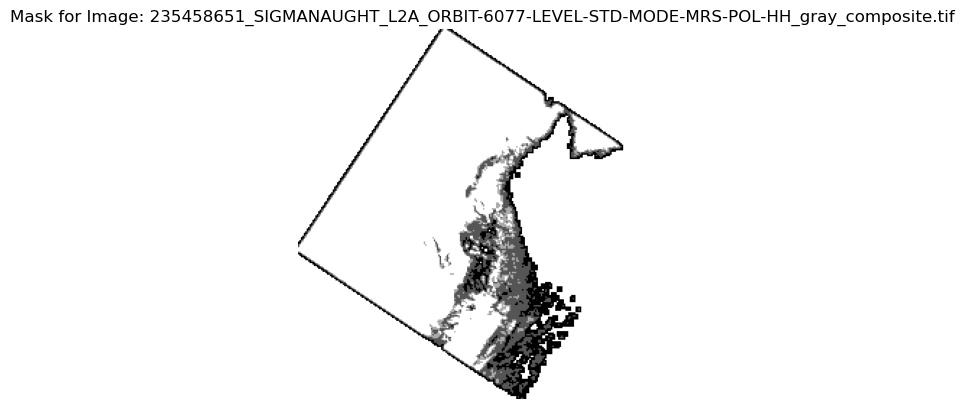

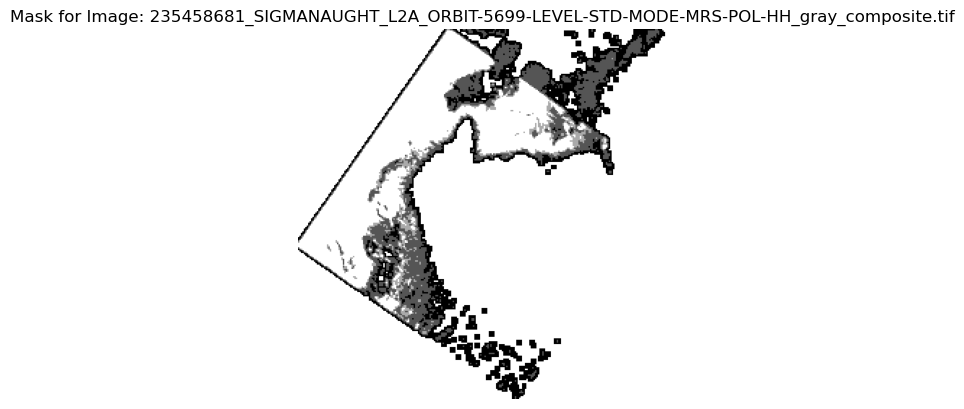

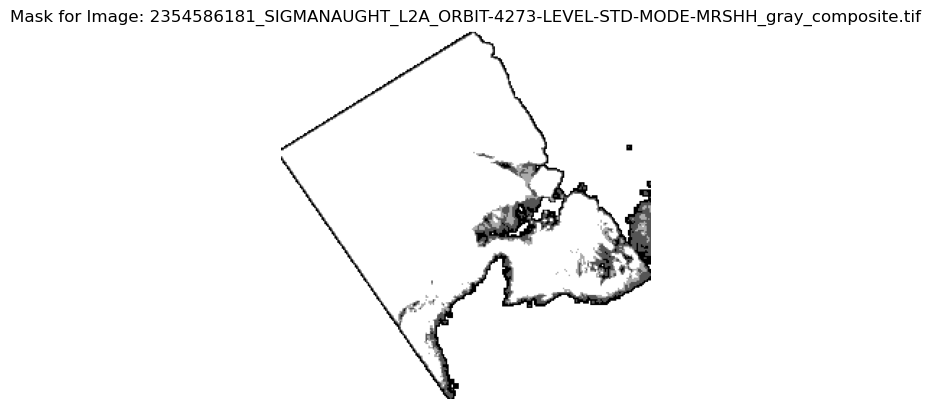

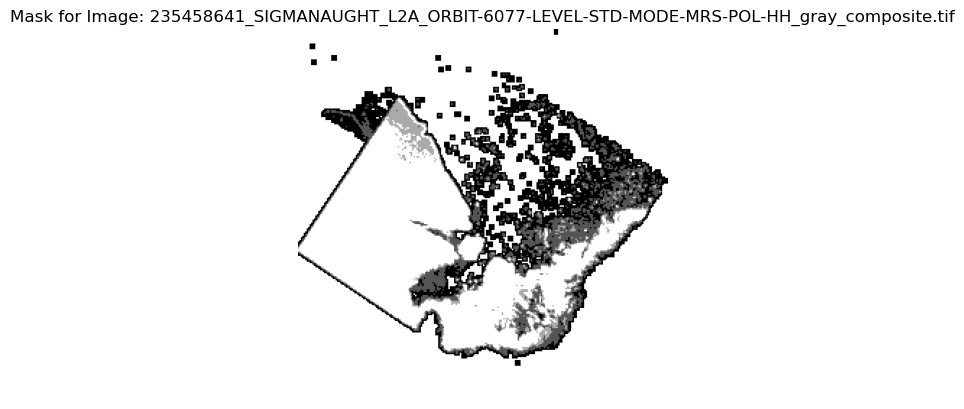

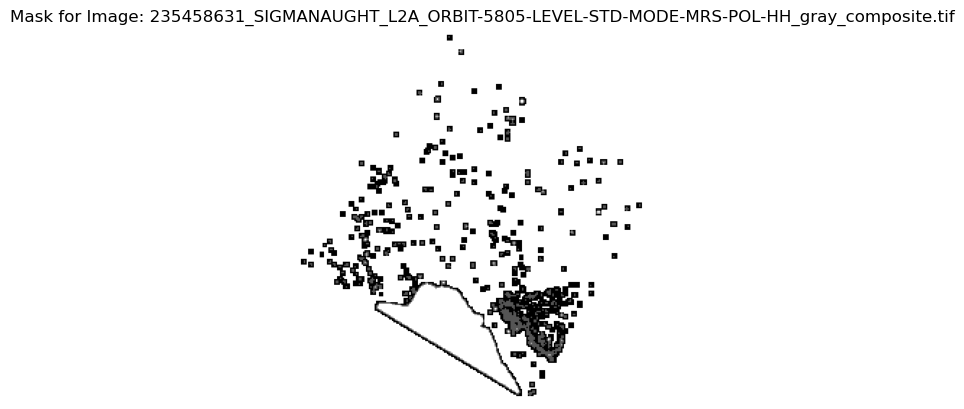

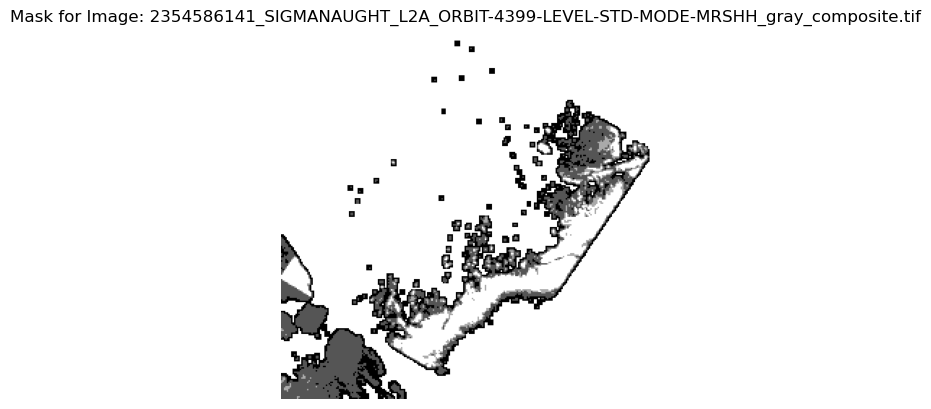

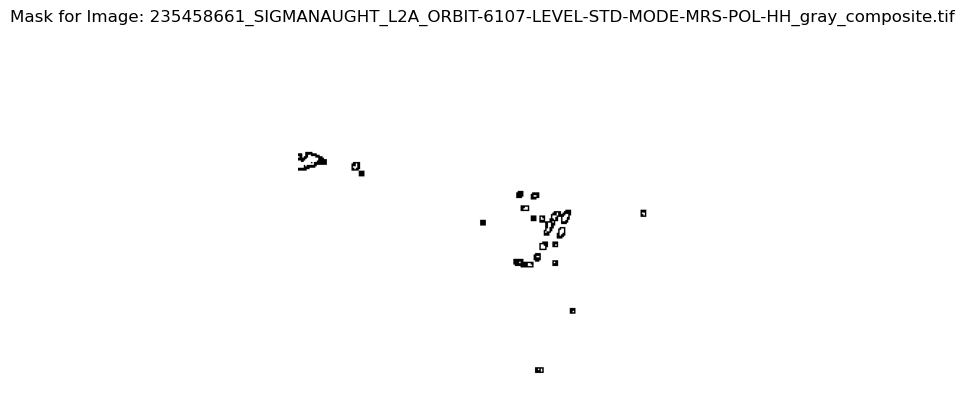

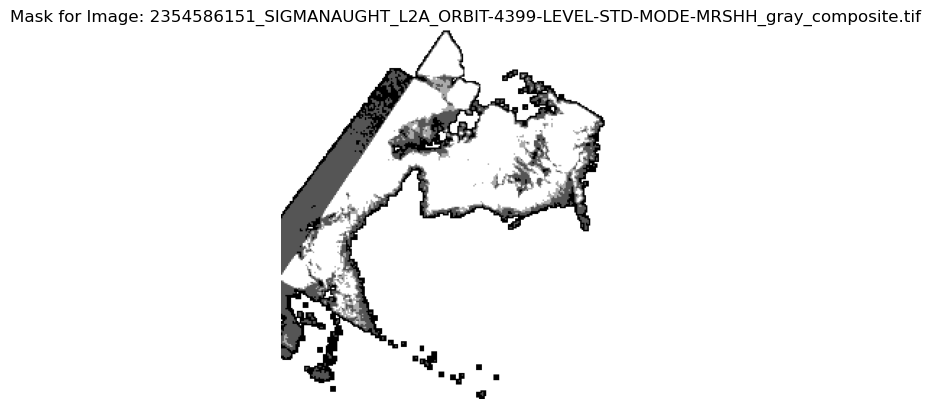

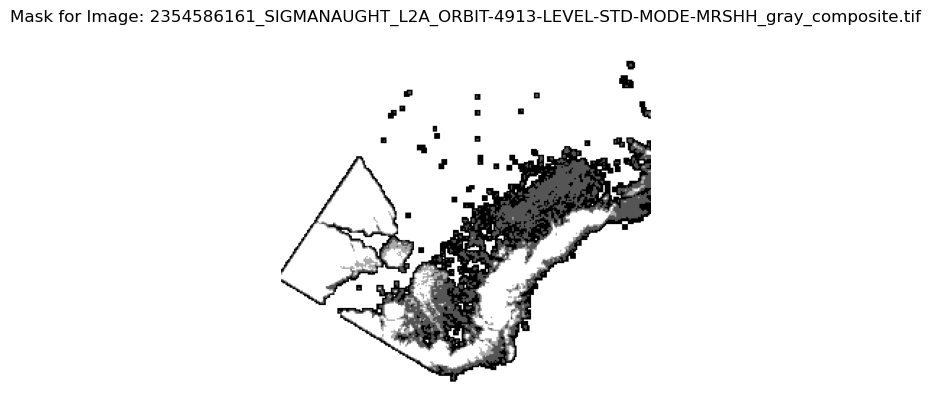

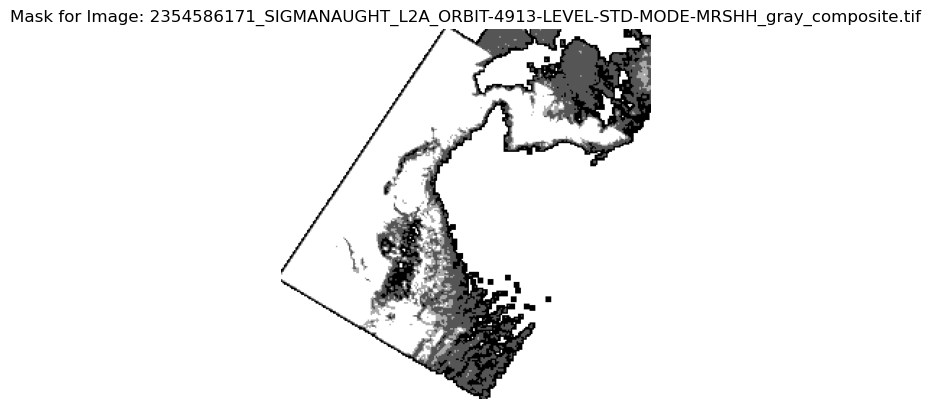

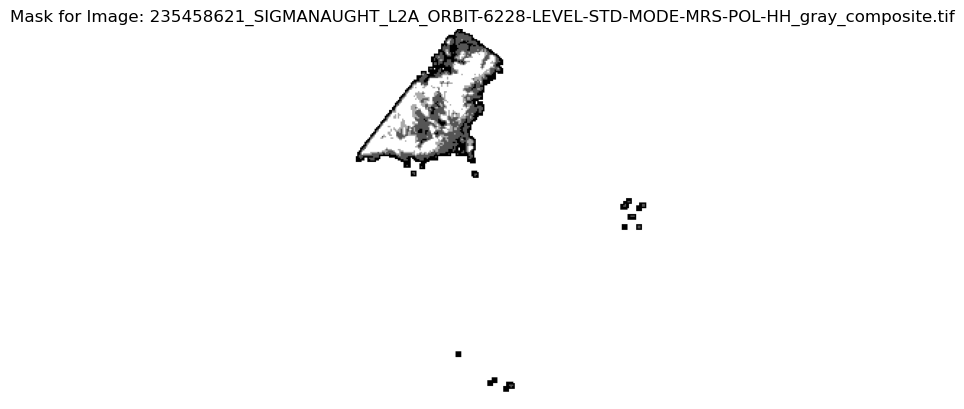

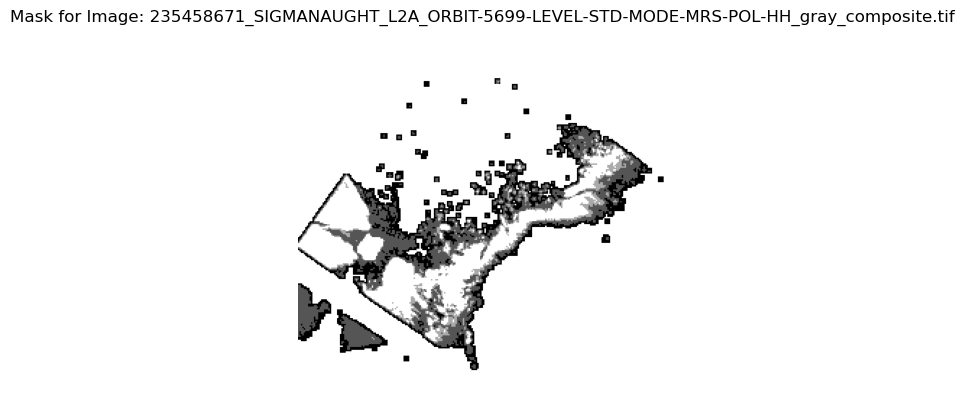

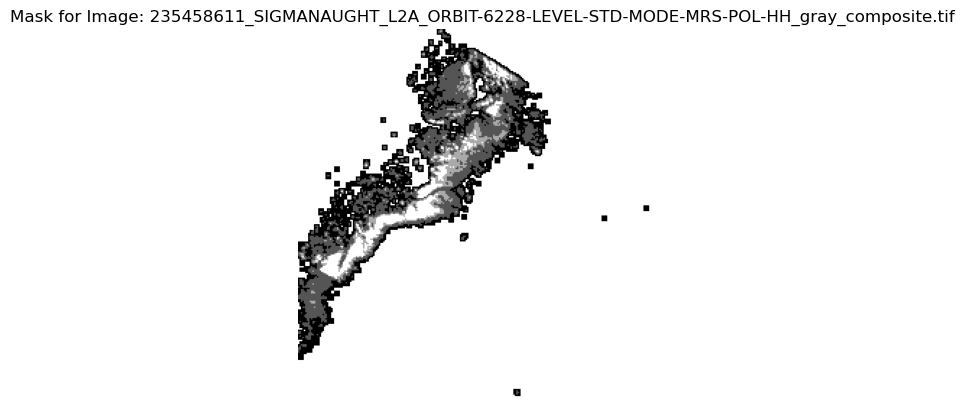

Shape of x (images): (13, 256, 256)
Shape of z (masks): (13, 256, 256)
Shape of y (labels): (13,)


In [8]:
#for composite images only

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
import os
import shutil
import tifffile as tiff
import matplotlib.pyplot as plt

def convert_to_db(image):
    with np.errstate(divide='ignore', invalid='ignore'):
        db_image = 10 * np.log10(image)
    return db_image

def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-np.inf,-15]  # Ice Free threshold
    threshold_ice_bergs = [0,5]  # Ice Covered threshold
    threshold_multiyearice = [5, np.inf]  # Multi-Year Ice threshold
    threshold_firstyearice = [-15, 0]  # First-Year Ice threshold

    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
    }

    return mask_lib

# Set the folder path where the images are located
folder_path = "d:/ISRO/Proj/working/input"  # Change this to the path of your image folder

# Set the folder where you want to save the masks
mask_output_folder = "d:/ISRO/Proj/working/combined-mask"  # Change this to your desired mask output folder path
if os.path.exists(mask_output_folder):
    shutil.rmtree(mask_output_folder)
os.makedirs(mask_output_folder)

# Lists to store images, masks, and labels
x = []
z = []
y = []

# Iterate through the images in the folder
for image_file in os.listdir(folder_path):
    if image_file.endswith(".tif"):
        image_path = os.path.join(folder_path, image_file)

        # Load and preprocess the SAR image
        image = tiff.imread(image_path)
        image = resize(image, (256, 256))
        db_image = convert_to_db(image)

        # Handle NaN and Inf values in db_image
        db_image[np.isnan(db_image)] = np.nanmin(db_image)
        finite_max = np.nanmax(db_image[np.isfinite(db_image)])
        db_image[np.isinf(db_image)] = finite_max + 1

        # Generate the mask library for the dB image
        mask_lib = generate_mask_lib(db_image)

        # Initialize an empty color mask image
        color_mask = np.zeros((db_image.shape[0], db_image.shape[1]), dtype=np.uint8)

        # Assign values for different ice types in the color mask image
        color_mask[mask_lib['Ice Free'] == 1] = 0      # Assign value 0 for Ice Free
        color_mask[mask_lib['Ice bergs'] == 1] = 2     # Assign value 2 for Ice bergs
        color_mask[mask_lib['Multi-Year Ice'] == 1] = 3   # Assign value 3 for Multi-Year Ice
        color_mask[mask_lib['First-Year Ice'] == 1] = 1   # Assign value 1 for First-Year Ice

        # Save the color mask image to the output folder with the image name
        mask_image_name = image_file.replace(".tif", "_color_mask.tif")
        mask_output_path = os.path.join(mask_output_folder, mask_image_name)  # Use the mask_output_folder
        tiff.imsave(mask_output_path, color_mask)

        # Add image, mask, and label to the lists
        x.append(image)
        z.append(color_mask)
        y.append(mask_lib)

        # Show the color mask image (optional)
        plt.imshow(color_mask, cmap='gray')
        plt.axis('off')
        plt.title("Mask for Image: " + image_file)
        plt.show()

#Convert lists to numpy arrays for further processing if needed
x = np.array(x)
z = np.array(z)
y = np.array(y)

# Print the shapes of the images, masks, and labels
print("Shape of x (images):", x.shape)
print("Shape of z (masks):", z.shape)
print("Shape of y (labels):", y.shape)

In [ ]:
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from skimage.transform import resize
# import os
# import shutil
# import tifffile as tiff
# import matplotlib.pyplot as plt

# def convert_to_db(image):
#     with np.errstate(divide='ignore', invalid='ignore'):
#         db_image = 10 * np.log10(image)
#     return db_image

# def assign_value_to_pixel(pixel, threshold_lib):
#     for value, threshold_range in threshold_lib.items():
#         if threshold_range[0] <= pixel <= threshold_range[1]:
#             return value
#     return 0  # Return 0 if no threshold range is matched

# def generate_mask_lib(db_image):
#     # Define the threshold values for different ice types in dB
#     threshold_lib = {
#         0: [-7, -2],        # Ice Free threshold
#         1: [-2, -1],      # First-Year Ice threshold
#         2: [-1, 3.5],     # Multi-Year Ice threshold
#         3: [3.5, np.inf]  # Ice Covered threshold
#     }

#     # Create a mask array based on the threshold values for each pixel
#     mask = np.zeros_like(db_image, dtype=np.uint8)
#     for i in range(db_image.shape[0]):
#         for j in range(db_image.shape[1]):
#             mask[i, j] = assign_value_to_pixel(db_image[i, j], threshold_lib)

#     return mask

# # Set the folder path where the images are located
# folder_path = "d:/ISRO/Proj/working/input"  # Change this to the path of your image folder

# # Set the folder where you want to save the masks
# mask_output_folder = "d:/ISRO/Proj/working/combined-mask"  # Change this to your desired mask output folder path
# if os.path.exists(mask_output_folder):
#     shutil.rmtree(mask_output_folder)
# os.makedirs(mask_output_folder)

# # Lists to store images and masks
# x = []
# z = []

# # Iterate through the images in the folder
# for image_file in os.listdir(folder_path):
#     if image_file.endswith(".tif"):
#         image_path = os.path.join(folder_path, image_file)

#         # Load and preprocess the SAR image
#         image = tiff.imread(image_path)
#         image = resize(image, (256, 256))
#         db_image = convert_to_db(image)

#         # Handle NaN and Inf values in db_image
#         db_image[np.isnan(db_image)] = np.nanmin(db_image)
#         finite_max = np.nanmax(db_image[np.isfinite(db_image)])
#         db_image[np.isinf(db_image)] = finite_max + 1

#         # Generate the mask array for the dB image
#         mask_array = generate_mask_lib(db_image)

#         # Save the grayscale mask image to the output folder with the image name
#         mask_image_name = image_file.replace(".tif", "_mask.tif")
#         mask_output_path = os.path.join(mask_output_folder, mask_image_name)  # Use the mask_output_folder
#         tiff.imsave(mask_output_path, mask_array, dtype=np.uint8)

#         # Append the image and mask arrays to their respective lists
#         x.append(image)
#         z.append(mask_array)

#         # Show the grayscale mask image (optional)
#         plt.imshow(mask_array, cmap='gray')
#         plt.axis('off')
#         plt.title("Mask for Image: " + image_file)
#         plt.show()

# # # Convert the lists to numpy arrays
# # x = np.array(x)
# # z = np.array(z)

# # # Print the shapes of the images and masks arrays
# # print("Shape of x (images):", x.shape)
# # print("Shape of z (masks):", z.shape)


In [ ]:
print(z)

In [ ]:
import numpy as np

# Assuming you have already loaded and processed the training data (x_train and z_train)

# Step 1: Print the unique values in z_train
unique_labels = np.unique(z)
print("Unique labels in z:", unique_labels)

# Step 2: Check if the labels are integers and within the correct range
num_classes = 4  # Assuming you have 4 classes (including the background class)
if np.issubdtype(z.dtype, np.integer):
    min_label = np.min(z)
    max_label = np.max(z)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# Convert the floating-point labels to integers based on the maximum probability
z_train_int = np.argmax(z, axis=-1)

# Verify the unique labels and check if they are integers and within the correct range
unique_labels_int = np.unique(z)
num_classes = 4  # Assuming you have 4 classes (including the background class)

if np.issubdtype(z.dtype, np.integer):
    min_label = np.min(z)
    max_label = np.max(z)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# Assuming num_classes = 4 (including the background class)
num_classes = 4

# Rescale the integer labels to be within the correct range (0 to num_classes - 1)
z_train_int_rescaled = (z / 255) * (num_classes - 1)

# Convert the rescaled labels back to integers
z_train_int_rescaled = np.round(z_train_int_rescaled).astype(int)

# Verify the unique labels and check if they are integers and within the correct range
unique_labels_int_rescaled = np.unique(z_train_int_rescaled)

min_label_rescaled = np.min(z_train_int_rescaled)
max_label_rescaled = np.max(z_train_int_rescaled)

if np.issubdtype(z_train_int_rescaled.dtype, np.integer):
    if min_label_rescaled >= 0 and max_label_rescaled <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label_rescaled, ", Maximum label:", max_label_rescaled)
else:
    print("Labels are not integers.")


In [ ]:
import numpy as np

# Assuming you have already loaded and processed the training data (x_train and z_train)

# Step 1: Print the unique values in z_train
unique_labels = np.unique(z)
print("Unique labels in z:", unique_labels)

# Step 2: Check if the labels are integers and within the correct range
num_classes = 4  # Assuming you have 4 classes (including the background class)
if np.issubdtype(z.dtype, np.integer):
    min_label = np.min(z)
    max_label = np.max(z)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# unique_classes = set([c for c in z.flatten() if c is not None])
# print("Unique class indices in z_train_mapped:", unique_classes)
# print("z_train_mapped has None values:", np.any(z == None))



In [ ]:
import os

# Folder path containing the TIF images
folder_path = "d:/ISRO/Proj/working/combined-mask"

# Get the list of image names in the folder
image_names = os.listdir(folder_path)

# Print the names of the TIF images
for image_name in image_names:
    if image_name.endswith(".tif"):
        print(image_name)


In [ ]:
import numpy as np
import os
import tifffile as tiff
import matplotlib.pyplot as plt

# Initialize an empty dictionary to store the counts for each ice type
ice_counts = {ice_type: 0 for ice_type in ['Ice Free', 'Ice bergs', 'Multi-Year Ice', 'First-Year Ice']}

# Total number of images
total_images = len(y)

# Iterate through the labels (y list)
for label in y:
    for ice_type, mask in label.items():
        ice_counts[ice_type] += np.sum(mask)

# Convert the counts to percentages of total pixels
total_pixels = 256 * 256 * total_images
ice_percentages = {ice_type: (count / total_pixels) * 100 for ice_type, count in ice_counts.items()}

# Generate the bar graph
ice_types = list(ice_percentages.keys())
percentages = list(ice_percentages.values())

plt.bar(ice_types, percentages)
plt.xlabel("Ice Types")
plt.ylabel("Percentage of Pixels")
plt.title("Ice Type Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# import numpy as np
# import cv2
# import os
# import matplotlib.pyplot as plt

# # Function to perform Min-Max normalization
# def normalize_backscattering(data):
#     min_value = np.min(data)
#     max_value = np.max(data)
#     normalized_data = 255 * (data - min_value) / (max_value - min_value)
#     normalized_data = normalized_data.astype(np.uint8)
#     return normalized_data

# # Folder path containing the TIFF files
# folder_path = 'd:/ISRO/Proj/HV_tiles'  # Replace this with the actual path to your folder

# # Output folder for the normalized TIFF files
# output_folder = 'd:/ISRO/Proj/working/norm_data'  # Replace this with the desired output path

# # Check if the folder exists
# if not os.path.exists(folder_path):
#     print(f"Folder not found: {folder_path}")
# else:
#     # Create the output folder if it doesn't exist
#     if not os.path.exists(output_folder):
#         os.makedirs(output_folder)

#     # Lists to store backscattering values and labels
#     backscattering_values = []
#     labels = []

#     # Loop through each TIFF file in the folder
#     for filename in os.listdir(folder_path):
#         if filename.endswith('.tiff') or filename.endswith('.tif'):
#             # Read the TIFF file
#             file_path = os.path.join(folder_path, filename)
#             backscattering_data = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

#             # Perform Min-Max normalization
#             normalized_data = normalize_backscattering(backscattering_data)

#             # Save the normalized data as a new TIFF file
#             new_filename = "normalized_" + filename
#             new_file_path = os.path.join(output_folder, new_filename)
#             cv2.imwrite(new_file_path, normalized_data)

#             # Get the corresponding label for the file
#             label = None  # Replace this with the code to get the label based on the filename or any other method
#             if label is not None:
#                 # Append the backscattering values and label to the lists
#                 backscattering_values.append(normalized_data)
#                 labels.append(label)

#     # Generate the boxplot graph for each ice type
#     plt.figure(figsize=(10, 6))
#     plt.boxplot(backscattering_values, labels=labels)
#     plt.xlabel("Ice Types")
#     plt.ylabel("Normalized Backscattering Values (0-255)")
#     plt.title("Backscattering Values Distribution by Ice Type")
#     plt.xticks(rotation=45)
#     plt.show()


In [ ]:
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from skimage.transform import resize
# import os
# import tifffile as tiff
# from PIL import Image
# import matplotlib.pyplot as plt

# def convert_to_db(image):
#     with np.errstate(divide='ignore', invalid='ignore'):
#         db_image = 10 * np.log10(image)
#     db_image[np.isinf(db_image)] = np.nan
#     return db_image

# def generate_mask_lib(db_image):
#     # Define the threshold values for different ice types in dB
#     threshold_ice_free = [-7,-2]  # Ice Free threshold
#     threshold_ice_bergs = [-1.5,-1]  # Ice Covered threshold
#     threshold_multiyearice = [-1, 3.5]  # Multi-Year Ice threshold
#     threshold_firstyearice = [-2, -1.5]  # First-Year Ice threshold


#     # Generate the mask library based on the dB image and threshold values
#     mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
#     mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
#     mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
#     mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])
#     #mask_icetype4 = (db_image >= threshold_icetype4[0]) & (db_image <= threshold_icetype4[1])
#     #mask_newice = (db_image >= threshold_newice[0]) & (db_image <= threshold_newice[1])

#     mask_lib = {
#         'Ice Free': mask_ice_free.astype(int),
#         'Ice bergs': mask_ice_bergs.astype(int),
#         'Multi-Year Ice': mask_multiyearice.astype(int),
#         'First-Year Ice': mask_firstyearice.astype(int),
#         #'Ice Type 4': mask_icetype4.astype(int),
#         #'New Ice': mask_newice.astype(int)
#     }

#     return mask_lib

# # Folder path containing the TIF images
# folder_path = "d:/ISRO/Proj/working/norm_data"
# folder_path2 = "d:/ISRO/Proj/working/combined-mask"

# # Initialize the dictionaries to store the percentages for each ice type
# total_percentages = {ice_type: 0 for ice_type in ['Ice Free', 'Ice bergs', 'Multi-Year Ice', 'First-Year Ice']}
# label_to_int = {'Ice Free': 2, 'Ice bergs': 16, 'Multi-Year Ice': 64, 'First-Year Ice': 128}

# num_images = 0
# y = []
# x = []
# z = []

# # Loop through the images in the folder
# for filename in os.listdir(folder_path):
#     if filename.endswith(".tif"):
#         # Load the SAR image
#         image_path = os.path.join(folder_path, filename)
#         image = tiff.imread(image_path)
#         image_array = np.array(image)

#         # Convert the SAR image to dB units
#         db_image = convert_to_db(image_array)

#         # Generate the mask library based on the dB image
#         mask_lib = generate_mask_lib(db_image)

#         # Generate the corresponding mask image filename
#         mask_filename = filename.replace(".tif", "_combined_mask.tif")
#         mask_path = os.path.join(folder_path2, mask_filename)

#         # Load the corresponding mask image
#         mask_image = tiff.imread(mask_path)
#         mask_array = np.array(mask_image)

#         # Resize the mask image to match the size of the original image
#         resized_mask = resize(mask_array, (256, 256))
#         z.append(resized_mask)

#         # Get the label from the filename
#         label = filename.split(".")[0]
#         label_encoded = label_to_int

#         # Encode the label using the mapping, use -1 as a default value
#         if label_encoded != -1:
#             y.append(label_encoded)

#         # Resize the image to a consistent size
#         resized_image = resize(image_array, (256, 256))

#         x.append(resized_image)

#         # Calculate the percentage of each ice type for the current image
#         percentages = {ice_type: np.mean(mask) * 100 for ice_type, mask in mask_lib.items()}

#         # Accumulate the percentages for all images
#         for ice_type in total_percentages:
#             total_percentages[ice_type] += percentages[ice_type]

#         num_images += 1

# # Convert the lists to arrays
# x = np.array(x)
# y = np.array(y)
# z = np.array(z)

# # Calculate the average percentages for all images
# for ice_type in total_percentages:
#     total_percentages[ice_type] /= num_images

# # Generate the bar graph for ice type distribution
# ice_types = list(total_percentages.keys())
# percentages = list(total_percentages.values())

# plt.bar(ice_types, percentages)
# plt.xlabel("Ice Types")
# plt.ylabel("Percentage of Pixels")
# plt.title("Ice Type Distribution")
# plt.xticks(rotation=45)
# plt.show()

In [9]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
import os
import shutil
import tifffile as tiff

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Define the directory to save the augmented images
augm_img = 'd:/ISRO/Proj/working/augm_img'
# Define the directory to save the augmented mask
augm_mask = 'd:/ISRO/Proj/working/augm_mask'

# Clear the directory for images if it exists and is not empty
if os.path.exists(augm_img):
    shutil.rmtree(augm_img)
os.makedirs(augm_img)
# Clear the directory for masks if it exists and is not empty
if os.path.exists(augm_mask):
    shutil.rmtree(augm_mask)
os.makedirs(augm_mask)

# Create augmented images and labels
print('Performing data augmentation')
num_augmented_samples = 10  # Number of augmented samples to generate per original image

# Function to apply data augmentation to the mask
def augment_mask(mask):
    mask[mask == 0] = 0   # Original mask value: 0 -> Augmented mask value: 85
    mask[mask == 1] = 1  # Original mask value: 1 -> Augmented mask value: 170
    mask[mask == 2] = 2  # Original mask value: 2 -> Augmented mask value: 255
    return mask.astype(np.uint8)

# Lists to store augmented images and masks
augmented_images = []
augmented_masks = []

for i in range(len(x)):
    img = x[i]
    mask = z[i]

    # Reshape the image to include the channel dimension
    img = np.reshape(img, (*img.shape, 1))
    # Reshape the mask to include the channel dimension
    mask = np.reshape(mask, (*mask.shape, 1))

    # Generate augmented images and masks
    img_augmented_gen = datagen.flow(np.expand_dims(img, axis=0), batch_size=1, shuffle=False)
    mask_augmented_gen = datagen.flow(np.expand_dims(mask, axis=0), batch_size=1, shuffle=False)

    for j in range(num_augmented_samples):
        img_augmented = img_augmented_gen.next()[0]
        mask_augmented = mask_augmented_gen.next()[0]

        # Resize the augmented image to a consistent size
        #img_augmented = resize(img_augmented, (256, 256))
        # Resize the augmented mask to a consistent size
        #mask_augmented = resize(mask_augmented, (256, 256))

        # Apply data augmentation to the mask (restore original mask values)
        mask_augmented = augment_mask(mask_augmented)

        # Save the augmented image and mask as TIFF files
        img_save_path = os.path.join(augm_img, f'image_{i}_{j}.tif')
        mask_save_path = os.path.join(augm_mask, f'image_{i}_{j}-mask.tif')

        tiff.imwrite(img_save_path, img_augmented)
        tiff.imwrite(mask_save_path, mask_augmented)

        # Append the augmented images and masks to their respective lists
        augmented_images.append(img_augmented)
        augmented_masks.append(mask_augmented)

# Convert the lists to arrays
augmented_images = np.array(augmented_images)
augmented_masks = np.array(augmented_masks)

# Print the shapes of the augmented images and masks arrays
print('Augmented images shape:', augmented_images.shape)
print('Augmented masks shape:', augmented_masks.shape)
print('Augmented images saved in:', augm_img)
print('Augmented masks saved in:', augm_mask)


Performing data augmentation
Augmented images shape: (130, 256, 256, 1)
Augmented masks shape: (130, 256, 256, 1)
Augmented images saved in: /kaggle/working/augm_img
Augmented masks saved in: /kaggle/working/augm_mask


In [ ]:
import numpy as np

# Assuming you have already loaded and processed the training data (x_train and z_train)

# Step 1: Print the unique values in z_train
unique_labels = np.unique(augmented_masks)
print("Unique labels in z:", unique_labels)

# Step 2: Check if the labels are integers and within the correct range
num_classes = 4  # Assuming you have 4 classes (including the background class)
if np.issubdtype(augmented_masks.dtype, np.integer):
    min_label = np.min(augmented_masks)
    max_label = np.max(augmented_masks)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# Convert the floating-point labels to integers based on the maximum probability
z_train_int = np.argmax(augmented_masks, axis=-1)

# Verify the unique labels and check if they are integers and within the correct range
unique_labels_int = np.unique(augmented_masks)
num_classes = 4  # Assuming you have 4 classes (including the background class)

if np.issubdtype(augmented_masks.dtype, np.integer):
    min_label = np.min(augmented_masks)
    max_label = np.max(augmented_masks)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# unique_classes = set([c for c in augmented_masks.flatten() if c is not None])
# print("Unique class indices in z_train_mapped:", unique_classes)
# print("z_train_mapped has None values:", np.any(augmented_masks == None))



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

# Set the folder path containing the images
folder_path = "d:/ISRO/Proj/working/augm_mask"

# Get a list of files in the folder
file_list = os.listdir(folder_path)

# Create a subplot grid to display the images
num_images = len(file_list)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Iterate over each file in the folder
for i, file_name in enumerate(file_list):
    # Check if the file is a TIFF image
    if file_name.endswith('.tif'):
        # Get the directory path of the image file
        file_path = os.path.join(folder_path, file_name)
        
        # Load and display the image
        image = tiff.imread(file_path)
        
        # Determine the subplot indices
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Display the image in the corresponding subplot
        axes[row_idx, col_idx].imshow(image, cmap='gray')
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

# Set the folder path containing the images
folder_path = "d:/ISRO/Proj/working/augm_img"

# Get a list of files in the folder
file_list = os.listdir(folder_path)

# Create a subplot grid to display the images
num_images = len(file_list)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Iterate over each file in the folder
for i, file_name in enumerate(file_list):
    # Check if the file is a TIFF image
    if file_name.endswith('.tif'):
        # Get the directory path of the image file
        file_path = os.path.join(folder_path, file_name)
        
        # Load and display the image
        image = tiff.imread(file_path)
        
        # Determine the subplot indices
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Display the image in the corresponding subplot
        axes[row_idx, col_idx].imshow(image, cmap='gray')
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
print(augmented_images.shape)
print(augmented_masks.shape)

In [ ]:
# for i in range(len(x)):
#     img = x[i]
#     mask = z[i]

#     # Reshape the image to include the channel dimension
#     X = np.expand_dims(x, axis=-1)
#     # Reshape the mask to include the channel dimension
#     Z= np.expand_dims(z, axis=-1)
# print(X.shape)
# print(Z.shape)

In [10]:
from sklearn.model_selection import train_test_split
import random

# Combine the augmented images and masks into a list of tuples
data = list(zip(augmented_images, augmented_masks))

# Shuffle the list of tuples
random.shuffle(data)

# Unpack the shuffled list of tuples back into separate lists
shuffled_images, shuffled_masks = zip(*data)

# Perform the train-test split on the shuffled lists
x_train, x_test, z_train, z_test = train_test_split(shuffled_images, shuffled_masks, test_size=0.2, random_state=0)

# Convert the lists to numpy arrays
x_train = np.array(x_train)
x_test = np.array(x_test)
z_train = np.array(z_train)
z_test = np.array(z_test)

# Print the shapes of the resulting splits 
print("Training data - Input:", x_train.shape)
print("Training data - Mask:", z_train.shape)
print("Test data - Input:", x_test.shape)
print("Test data - Mask:", z_test.shape)


Training data - Input: (104, 256, 256, 1)
Training data - Mask: (104, 256, 256, 1)
Test data - Input: (26, 256, 256, 1)
Test data - Mask: (26, 256, 256, 1)


In [ ]:
import numpy as np

# Assuming you have already loaded and processed the training data (x_train and z_train)

# Step 1: Print the unique values in z_train
unique_labels = np.unique(z_train)
print("Unique labels in z_train:", unique_labels)

# Step 2: Check if the labels are integers and within the correct range
num_classes = 4  # Assuming you have 4 classes (including the background class)
if np.issubdtype(z_train.dtype, np.integer):
    min_label = np.min(z_train)
    max_label = np.max(z_train)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [12]:
from sklearn.model_selection import train_test_split
import shutil
import os
import tifffile as tiff

# Define the destination directories for train and test data of x
x_train_dest = "d:/ISRO/Proj/working/x_train"
x_test_dest = "d:/ISRO/Proj/working/x_test"
# Define the destination directories for train and test data of z
z_train_dest = "d:/ISRO/Proj/working/z_train"
z_test_dest = "d:/ISRO/Proj/working/z_test"

# Clear the directories if they exist and are not empty
for directory in [x_train_dest, x_test_dest, z_train_dest, z_test_dest]:
    if os.path.exists(directory):
        shutil.rmtree(directory)
    os.makedirs(directory)

# Loop over the x_train data and store in the train directory
for i, x_train_data in enumerate(x_train):
    file_name = f"x_train_{i}.tif"  # Replace with the actual file name if available
    x_train_path = os.path.join(x_train_dest, file_name)
    
    # Save the x_train_data as a TIFF file
    tiff.imsave(x_train_path, x_train_data)

# Loop over the x_test data and store in the test directory
for i, x_test_data in enumerate(x_test):
    file_name = f"x_test_{i}.tif"  # Replace with the actual file name if available
    x_test_path = os.path.join(x_test_dest, file_name)

    # Save the x_test_data as a TIFF file
    tiff.imsave(x_test_path, x_test_data)

# Loop over the z_train data and store in the train directory
for i, z_train_data in enumerate(z_train):
    file_name = f"z_train_{i}.tif"  # Replace with the actual file name if available
    z_train_path = os.path.join(z_train_dest, file_name)

    # Save the z_train_data as a TIFF file
    tiff.imsave(z_train_path, z_train_data)

# Loop over the z_test data and store in the test directory
for i, z_test_data in enumerate(z_test):
    file_name = f"z_test_{i}.tif"  # Replace with the actual file name if available
    z_test_path = os.path.join(z_test_dest, file_name)

    # Save the z_test_data as a TIFF file
    tiff.imsave(z_test_path, z_test_data)


In [ ]:
import numpy as np

# Assuming you have already loaded and processed the training data (x_train and z_train)

# Step 1: Print the unique values in z_train
unique_labels = np.unique(z_train)
print("Unique labels in z_train:", unique_labels)

# Step 2: Check if the labels are integers and within the correct range
num_classes = 4  # Assuming you have 4 classes (including the background class)
if np.issubdtype(z_train.dtype, np.integer):
    min_label = np.min(z_train)
    max_label = np.max(z_train)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# Convert the floating-point labels to integers based on the maximum probability
z_train_int = np.argmax(z, axis=-1)

# Verify the unique labels and check if they are integers and within the correct range
unique_labels_int = np.unique(z)
num_classes = 4  # Assuming you have 4 classes (including the background class)

if np.issubdtype(z_train_int.dtype, np.integer):
    min_label = np.min(z_train_int)
    max_label = np.max(z_train_int)
    if min_label >= 0 and max_label <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label, ", Maximum label:", max_label)
else:
    print("Labels are not integers.")


In [ ]:
# Assuming num_classes = 4 (including the background class)
num_classes = 4

# Rescale the integer labels to be within the correct range (0 to num_classes - 1)
z_train_int_rescaled = (z_train_int / 255) * (num_classes - 1)

# Convert the rescaled labels back to integers
z_train_int_rescaled = np.round(z_train_int_rescaled).astype(int)

# Verify the unique labels and check if they are integers and within the correct range
unique_labels_int_rescaled = np.unique(z_train_int_rescaled)

min_label_rescaled = np.min(z_train_int_rescaled)
max_label_rescaled = np.max(z_train_int_rescaled)

if np.issubdtype(z_train_int_rescaled.dtype, np.integer):
    if min_label_rescaled >= 0 and max_label_rescaled <= (num_classes - 1):
        print("Labels are integers and within the correct range (0 to", num_classes - 1, ")")
    else:
        print("Labels are integers, but they are not within the correct range.")
        print("Minimum label:", min_label_rescaled, ", Maximum label:", max_label_rescaled)
else:
    print("Labels are not integers.")


In [13]:
import os
import tensorflow as tf
import tifffile as tiff
import numpy as np

x_train_dest = "d:/ISRO/Proj/working/x_train"
x_test_dest = "d:/ISRO/Proj/working/x_test"
z_train_dest = "d:/ISRO/Proj/working/z_train"
z_test_dest = "d:/ISRO/Proj/working/z_test"

def read_image(image_name):
    def _read_image(image_name):
        image_name_str = image_name.numpy().decode('utf-8')  # Convert image_name tensor to a string
        image = tiff.imread(os.path.join(x_train_dest, image_name_str))
        image = tf.convert_to_tensor(image, dtype=tf.float32) / 255.0

        mask = tiff.imread(os.path.join(z_train_dest, f"{image_name_str.split('.')[0]}-mask.tif"))
        mask = tf.convert_to_tensor(mask, dtype=tf.uint8)
        return image, mask

    return tf.py_function(_read_image, [image_name], [tf.float32, tf.uint8])

# List all files in the x_train folder and x_test folder
x_train_list = np.array([file for file in os.listdir(x_train_dest) if file.endswith(".tif")])
x_test_list = np.array([file for file in os.listdir(x_test_dest) if file.endswith(".tif")])

TRAIN_LENGTH = len(x_train_list)
VAL_LENGTH = len(x_test_list)
BATCH_SIZE = 4
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

ds_train = tf.data.Dataset.from_tensor_slices(x_train_list)
ds_train = ds_train.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = ds_train.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices(x_test_list)
ds_val = ds_val.map(read_image)
val_dataset = ds_val.batch(BATCH_SIZE)


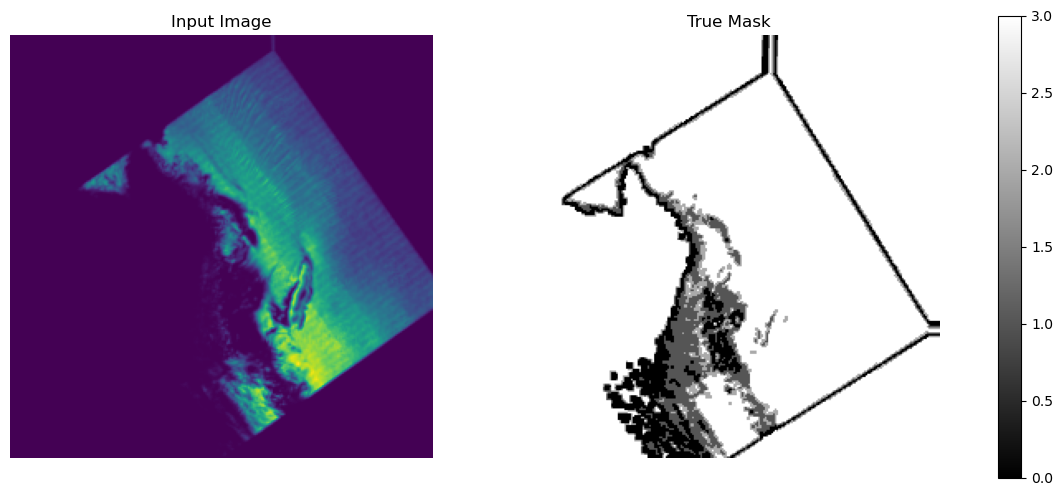

In [14]:
import matplotlib.cm as cm
def display(display_list):
    fig, axs = plt.subplots(nrows=1, ncols=len(display_list), figsize=(15, 6))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    cmap = cm.get_cmap('gray')  # Use 'gray' colormap

    for i in range(len(display_list)):
        axs[i].set_title(title[i])
        if i == 0:
            # For the input image, we need to convert the tensor back to an array
            #image_array = np.expand_dims(display_list[i], axis=-1)  # Add channel dimension
            axs[i].imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        else:
            # For masks, we can directly display the NumPy array
            msk = axs[i].imshow(display_list[i], cmap=cmap)
        axs[i].axis('off')

    # Plot colorbar for the mask
    cbar = fig.colorbar(msk, ax=axs)
    plt.show()

# Get an iterator for the dataset
x_train_iter = iter(x_train)
z_train_iter = iter(z_train)

# Get a single image and mask from the iterator
image = next(x_train_iter)
mask = next(z_train_iter)

# Display the image and mask
display([image, mask])


In [ ]:
# from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
# from keras.models import Model
# import matplotlib.pyplot as plt

# def get_unet():
#     inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1))
#     conv1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
#     conv1 = Conv2D(32, 3, activation='relu', padding='same')(conv1)
#     pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
#     drop1 = Dropout(0.5)(pool1)

#     conv2 = Conv2D(64, 3, activation='relu', padding='same')(drop1)
#     conv2 = Conv2D(64, 3, activation='relu', padding='same')(conv2)
#     pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
#     drop2 = Dropout(0.5)(pool2)

#     conv3 = Conv2D(128, 3, activation='relu', padding='same')(drop2)
#     conv3 = Conv2D(128, 3, activation='relu', padding='same')(conv3)
#     pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
#     drop3 = Dropout(0.5)(pool3)

#     conv4 = Conv2D(256, 3, activation='relu', padding='same')(drop3)
#     conv4 = Conv2D(256, 3, activation='relu', padding='same')(conv4)
#     pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
#     drop4 = Dropout(0.5)(pool4)

#     conv5 = Conv2D(512, 3, activation='relu', padding='same')(drop4)
#     conv5 = Conv2D(512, 3, activation='relu', padding='same')(conv5)

#     up6 = Conv2D(256, 3, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv5))
#     merge6 = concatenate([up6, conv4], axis=3)
#     drop6 = Dropout(0.5)(merge6)
#     conv6 = Conv2D(256, 3, activation='relu', padding='same')(drop6)
#     conv6 = Conv2D(256, 3, activation='relu', padding='same')(conv6)

#     up7 = Conv2D(128, 3, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv6))
#     merge7 = concatenate([up7, conv3], axis=3)
#     drop7 = Dropout(0.5)(merge7)
#     conv7 = Conv2D(128, 3, activation='relu', padding='same')(drop7)
#     conv7 = Conv2D(128, 3, activation='relu', padding='same')(conv7)

#     up8 = Conv2D(64, 3, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv7))
#     merge8 = concatenate([up8, conv2], axis=3)
#     drop8 = Dropout(0.5)(merge8)
#     conv8 = Conv2D(64, 3, activation='relu', padding='same')(drop8)
#     conv8 = Conv2D(64, 3, activation='relu', padding='same')(conv8)

#     up9 = Conv2D(32, 3, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv8))
#     merge9 = concatenate([up9, conv1], axis=3)
#     drop9 = Dropout(0.5)(merge9)
#     conv9 = Conv2D(32, 3, activation='relu', padding='same')(drop9)
#     conv9 = Conv2D(32, 3, activation='relu', padding='same')(conv9)

#     conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)

#     model = Model(inputs=inputs, outputs=conv10)
#     return model

# IMG_SIZE = (256, 256)
# cmap = plt.cm.get_cmap('viridis')   # New colormap
# n_colors = len(cmap.colors)
# model = get_unet()
# model.summary()


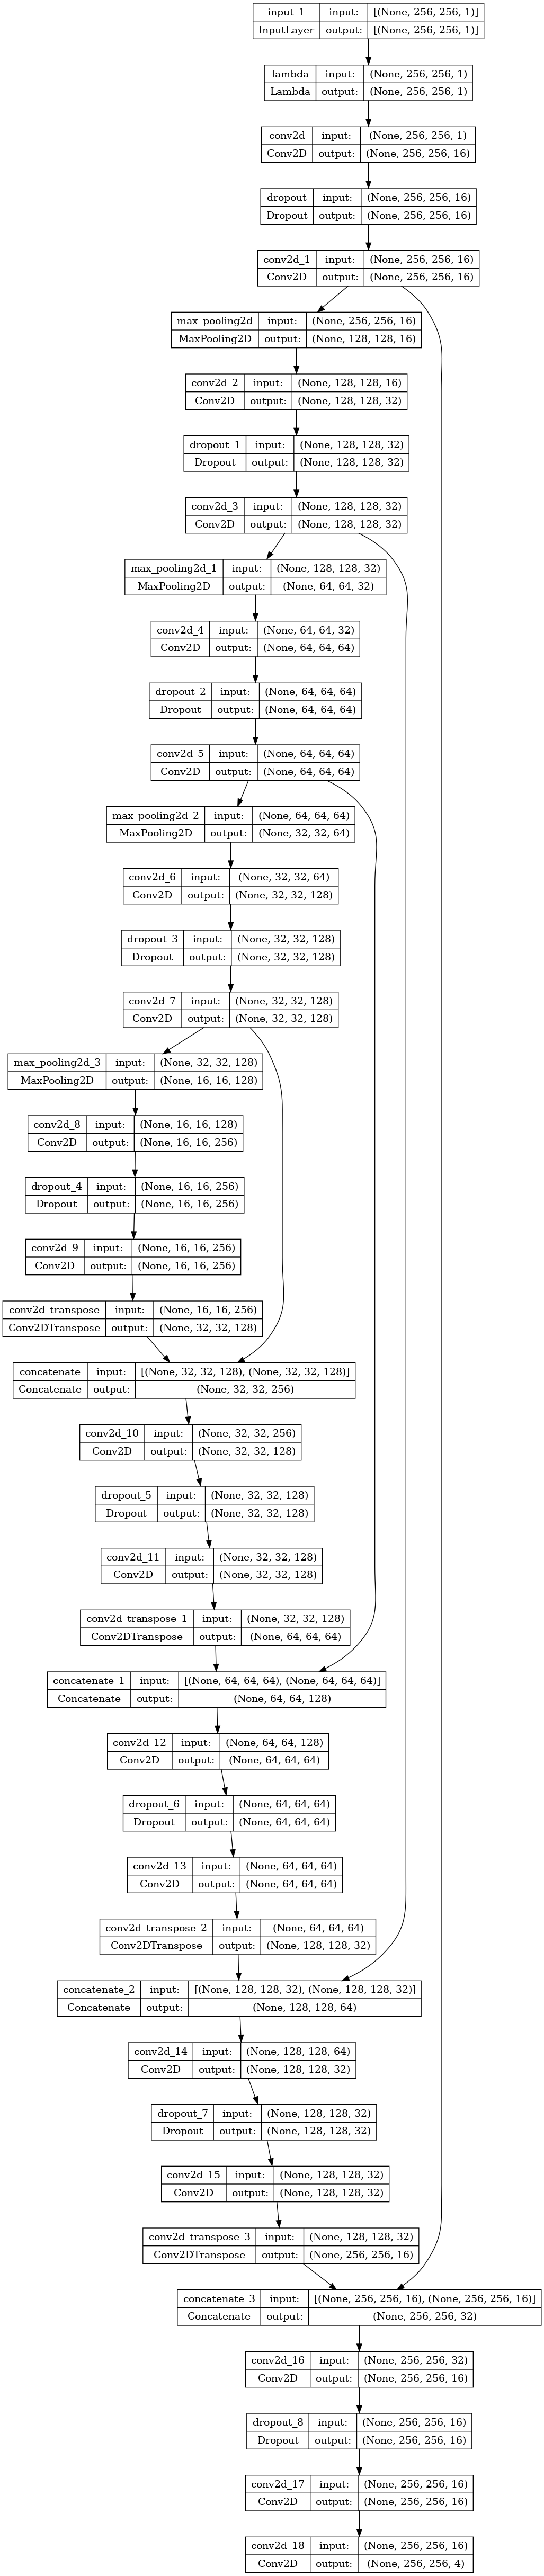

In [15]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras import Model
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 1
def get_unet(input_shape):
    inputs = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)

    #Contraction path
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path 
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    # Inside the get_unet function
    outputs = tf.keras.layers.Conv2D(4, (1, 1), activation='softmax')(c9)


    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model
IMG_SIZE = (256, 256,1)
cmap = plt.cm.get_cmap('viridis')   # New colormap
n_colors = len(cmap.colors)
model = get_unet(IMG_SIZE) 
tf.keras.utils.plot_model(model, show_shapes=True)

In [16]:
#function to generate a mask from the model predictions
def create_mask(pred_mask, ele=0):
    pred_mask = tf.argmax(pred_mask, axis=-1)#use the highest proabbaility class as the prediction
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[ele]

#helper functions to plot image, mask, and predicted mask while training
def show_predictions(dataset=None, num=1, ele=0):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[ele], mask[ele], create_mask(pred_mask, ele)])
    else:
        display([image, mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

#function to display loss during training
def plot_loss_acc(loss, val_loss, epoch):#, acc, val_acc, epoch):
    
    epochs = range(epoch+1)
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))

    ax.plot(epochs, loss, 'r', label='Training loss')
    ax.plot(epochs, val_loss, 'bo', label='Validation loss')
    ax.set_title('Training and Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss Value')
    ax.legend()
    plt.show()
    
#callback to clear output and show predictions
from IPython.display import clear_output

class DisplayCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.loss = []
        self.val_loss = []
    
    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        
        self.loss.append(logs['loss'])
        self.val_loss.append(logs['val_loss'])
        
        show_predictions()
        plot_loss_acc(self.loss, self.val_loss, epoch)
        
#callback to reduce learning rate when loss plateaus
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=8, verbose=1,)

#Define IoU metric (by stack overflow user HuckleberryFinn)
class UpdatedMeanIoU(tf.keras.metrics.MeanIoU):
    def __init__(self,
               y_true=None,
               y_pred=None,
               num_classes=None,
               name=None,
               dtype=None):
        super(UpdatedMeanIoU, self).__init__(num_classes = num_classes,name=name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.math.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)

# Create a callback that saves the model's weights
checkpoint_path = "training/cp-{epoch:04d}.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights every 5 epochs
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path, 
    verbose=1, 
    save_weights_only=True,
    save_freq=5*BATCH_SIZE)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(z_train.shape)
print(z_test.shape)

In [ ]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2),
    tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'),
    tf.keras.callbacks.TensorBoard(log_dir='./logs'),
]

In [ ]:
# # Define a mapping dictionary for your specific labels
# label_mapping = {2: 0, 16: 1, 64: 2, 128: 3}  # Adjust this mapping according to your dataset

# # Apply the mapping to convert the labels in z_train and z_test
# z_train_mapped = np.vectorize(label_mapping.get)(z_train)
# z_test_mapped = np.vectorize(label_mapping.get)(z_test)

# # Now, z_train_mapped and z_test_mapped should contain values 0, 1, 2, ... representing the class indices.

In [ ]:
print("x_train shape:", x_train.shape)
print("z_train shape:", z_train.shape)
print("x_test shape:", x_test.shape)
print("z_test shape:", z_test.shape)


In [ ]:
print("x_train has None values:", np.any(x_train == None))
print("z_train has None values:", np.any(z_train == None))


In [ ]:
print("Type of x_train:", type(x_train))
print("Type of z_train:", type(z_train))
print("Type of x_test:", type(x_test))
print("Type of z_test:", type(z_test))


In [ ]:
# # Convert z_train_mapped to a Python list, filter out None values, and find unique class indices
# unique_classes = set([c for c in z_train.flatten() if c is not None])
# print("Unique class indices in z_train:", unique_classes)


In [ ]:
print("z_train has None values:", np.any(z_train == None))


In [ ]:
# # Assuming you have 4 classes with labels 2, 16, 64, and 128
# label_mapping = {2: 0, 16: 1, 64: 2, 128: 3}
# z_train_mapped = np.vectorize(label_mapping.get)(z_train)
# unique_classes = set([c for c in z_train_mapped.flatten() if c is not None])
# print("Unique class indices in z_train_mapped:", unique_classes)


In [ ]:
x_train.shape

In [ ]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2),
    tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'),
    tf.keras.callbacks.TensorBoard(log_dir='./logs'),
]

In [17]:
from tensorflow.keras.utils import to_categorical

# Convert the mask data to one-hot encoded format
from tensorflow.keras.utils import to_categorical

# Convert the mask data to one-hot encoded format
z_train_one_hot = to_categorical(z_train, num_classes=4)
z_test_one_hot = to_categorical(z_test, num_classes=4)
print(z_train_one_hot.shape)
print(z_test_one_hot.shape)

# Now the shape of z_train_one_hot will be (104, 256, 256, 4)


(104, 256, 256, 4)
(26, 256, 256, 4)


In [ ]:
# #train model
# model=get_unet()
# model.compile(optimizer=tf.keras.optimizers.Adam(), 
#               loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), 
#               metrics=['categorical_accuracy', UpdatedMeanIoU(num_classes=4)],
#               run_eagerly=True)

# EPOCHS = 10
# VAL_SUBSPLITS = 5
# VALIDATION_STEPS = VAL_LENGTH//BATCH_SIZE//VAL_SUBSPLITS

# model_history = model.fit(x_train, 
#                           z_train,
#                           epochs=EPOCHS,
#                           steps_per_epoch=STEPS_PER_EPOCH,
#                           validation_steps=VALIDATION_STEPS,
#                           validation_data=(x_test, z_test),
#                           #callbacks=[DisplayCallback(), lr_callback, cp_callback]
#                          )

# # Retrieve validation loss and accuracy from the model history
# val_loss = model_history.history['loss']
# val_acc = model_history.history['categorical_accuracy']

# print("Validation Loss:", val_loss)
# print("Validation Accuracy:", val_acc)

In [18]:
class CustomIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='custom_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.total_samples = self.add_weight(name='total_samples', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.argmax(y_true, axis=-1)
        iou = []
        for i in range(self.num_classes):
            intersection = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, i), tf.equal(y_pred, i)), dtype=tf.float32))
            union = tf.reduce_sum(tf.cast(tf.logical_or(tf.equal(y_true, i), tf.equal(y_pred, i)), dtype=tf.float32))
            iou.append(intersection / union)
        self.total_iou.assign_add(tf.reduce_mean(iou))
        self.total_samples.assign_add(1)

    def result(self):
        return self.total_iou / self.total_samples

#train model
model=get_unet(IMG_SIZE)
model.compile(optimizer=tf.keras.optimizers.Adam(), 
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), 
              metrics=['categorical_accuracy', CustomIoU(num_classes=4)],
              run_eagerly=True)

EPOCHS = 2
VAL_SUBSPLITS = 5
VALIDATION_STEPS = VAL_LENGTH//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(x_train, 
                          z_train_one_hot,
                          epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=(x_test, z_test_one_hot),
                          #callbacks=[DisplayCallback(), lr_callback, cp_callback]
                         )

# Retrieve validation loss and accuracy from the model history
val_loss = model_history.history['loss']
val_acc = model_history.history['categorical_accuracy']

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


Epoch 1/2
26/26 [==============================] - 77s 3s/step - loss: 1.1841 - categorical_accuracy: 0.7054 - custom_iou: 0.1834 - val_loss: 0.9239 - val_categorical_accuracy: 0.7173 - val_custom_iou: 0.1793
Epoch 2/2
26/26 [==============================] - 71s 3s/step - loss: 0.8288 - categorical_accuracy: 0.7584 - custom_iou: 0.1896 - val_loss: 0.8650 - val_categorical_accuracy: 0.7173 - val_custom_iou: 0.1793
Validation Loss: [1.1841260194778442, 0.8288143873214722]
Validation Accuracy: [0.7054430246353149, 0.7583777904510498]


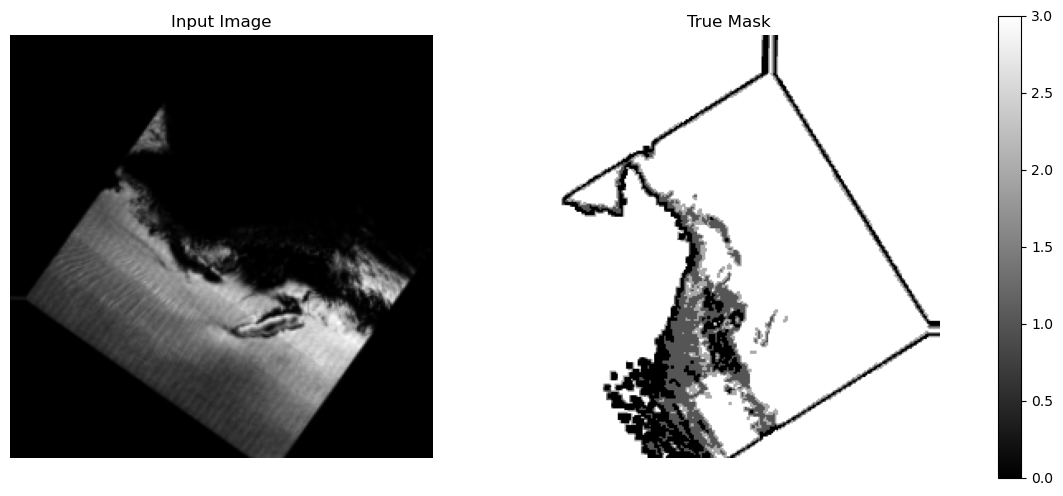

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def display(display_list):
    fig, axs = plt.subplots(nrows=1, ncols=len(display_list), figsize=(15, 6))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    cmap = cm.get_cmap('gray')  # Use 'gray' colormap

    for i in range(len(display_list)):
        axs[i].set_title(title[i])
        if i == 0:
            # Convert 3D tensor to 2D tensor and then transpose
            axs[i].imshow(tf.transpose(tf.squeeze(display_list[i]), perm=[1, 0]), cmap=cmap)
        else:
            msk = axs[i].imshow(display_list[i], cmap=cmap)
        axs[i].axis('off')

    # Plot colorbar
    cbar = fig.colorbar(msk, ax=axs)
    plt.show()

# Get an iterator for the dataset
x_train_iter = iter(x_train)
z_train_iter = iter(z_train)

# Get a single image and mask from the iterator
image = next(x_train_iter)
mask = next(z_train_iter)

# Display the image and mask
display([image, mask])


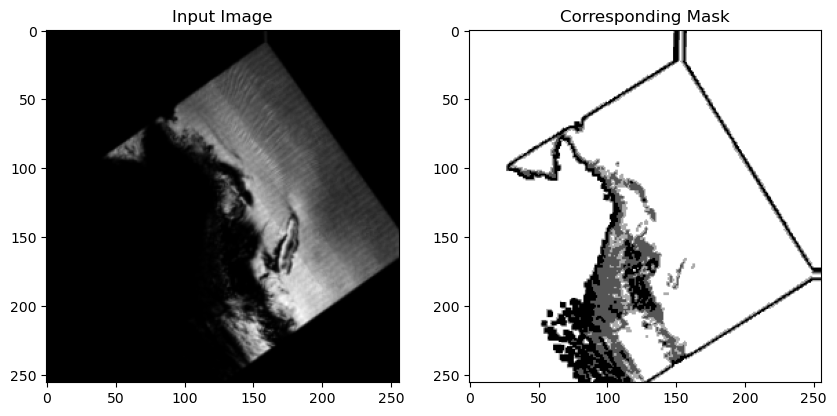

In [20]:
import matplotlib.pyplot as plt
import tifffile as tiff

# Visualize the first sample
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0].squeeze(), cmap='gray')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.imshow(z_train[0].squeeze(), cmap='gray')
plt.title('Corresponding Mask')
plt.show()


In [21]:
print(np.unique(z_train))


[0 1 2 3]


In [22]:
pred = model.predict(x_test)

1/1 [==============================] - 3s 3s/step


In [23]:
print(model_history.history.keys())


dict_keys(['loss', 'categorical_accuracy', 'custom_iou', 'val_loss', 'val_categorical_accuracy', 'val_custom_iou'])


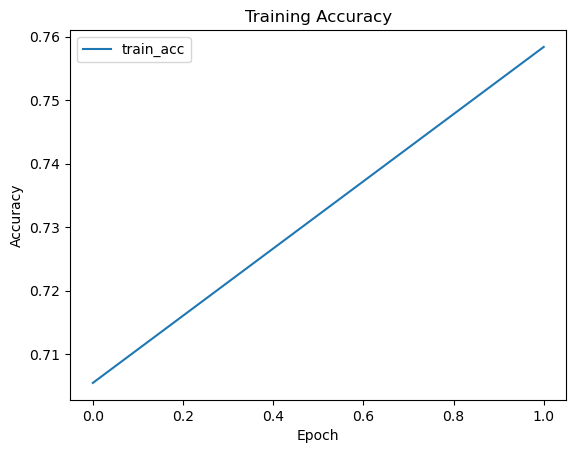

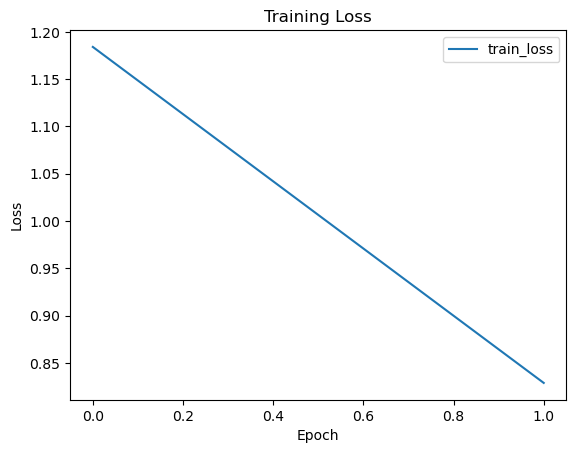

In [24]:
import matplotlib.pyplot as plt

# Plot accuracy per iteration
plt.plot(model_history.history['categorical_accuracy'], label='train_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.show()

# Plot loss per iteration
plt.plot(model_history.history['loss'], label='train_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


In [25]:
#Model for prediction

# Randomly select an image index for prediction
random_img_index = random.randint(0, len(x_test) - 1)
original_img = x_test[random_img_index]

# Preprocess the input image for prediction
input_img = np.expand_dims(original_img, axis=0)
input_img_normalized = input_img / 255.0  # Normalize input image

# Predict the mask using the U-Net model
predicted_mask = model.predict(input_img_normalized)
print(predicted_mask)
print(predicted_mask.shape)


1/1 [==============================] - 0s 182ms/step
(1, 256, 256, 4)


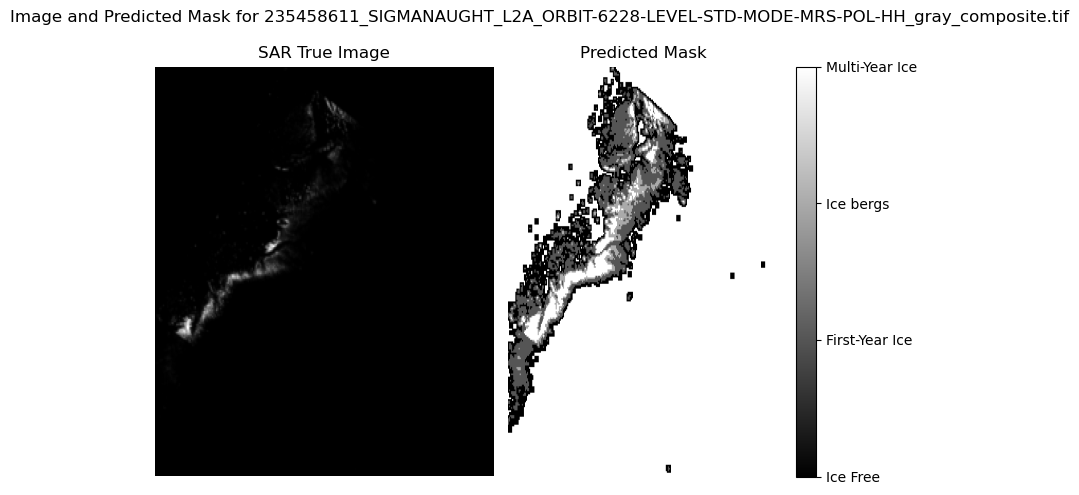

In [26]:
#Prediction of Random Single Selected Image

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
import os
import shutil
import tifffile as tiff
import matplotlib.pyplot as plt

def convert_to_db(image):
    with np.errstate(divide='ignore', invalid='ignore'):
        db_image = 10 * np.log10(image)
    return db_image

def generate_mask_lib(db_image):
    # Define the threshold values for different ice types in dB
    threshold_ice_free = [-np.inf,-15]  # Ice Free threshold
    threshold_ice_bergs = [0,5]  # Ice Covered threshold
    threshold_multiyearice = [5, np.inf]  # Multi-Year Ice threshold
    threshold_firstyearice = [-15, 0]  # First-Year Ice threshold
    

    # Generate the mask library based on the dB image and threshold values
    mask_ice_free = (db_image >= threshold_ice_free[0]) & (db_image <= threshold_ice_free[1])
    mask_firstyearice = (db_image >= threshold_firstyearice[0]) & (db_image <= threshold_firstyearice[1])
    mask_ice_bergs = (db_image >= threshold_ice_bergs[0]) & (db_image <= threshold_ice_bergs[1])
    mask_multiyearice = (db_image >= threshold_multiyearice[0]) & (db_image <= threshold_multiyearice[1])
    

    mask_lib = {
        'Ice Free': mask_ice_free.astype(int),
        'First-Year Ice': mask_firstyearice.astype(int),
        'Ice bergs': mask_ice_bergs.astype(int),
        'Multi-Year Ice': mask_multiyearice.astype(int),
    }

    return mask_lib

# Set the folder where you want to save the masks
mask_output_folder = "d:/ISRO/Proj/working/predicted_mask"  # Change this to your desired mask output folder path
if os.path.exists(mask_output_folder):
    shutil.rmtree(mask_output_folder)
os.makedirs(mask_output_folder)

# Lists to store images, masks, and labels
x = []
z = []
y = []


image = original_img.copy()  # You may need to preprocess your image array here
db_image = convert_to_db(image)
# Load and preprocess the SAR image
image = tiff.imread(image_path)
# Resize with different interpolation methods
image = resize(image, (256, 256), anti_aliasing=True, mode='reflect') 
db_image = convert_to_db(image)

# Handle NaN and Inf values in db_image
db_image[np.isnan(db_image)] = np.nanmin(db_image)
finite_max = np.nanmax(db_image[np.isfinite(db_image)])
db_image[np.isinf(db_image)] = finite_max + 1

# Generate the mask library for the dB image
mask_lib = generate_mask_lib(db_image)

# Initialize an empty color mask image
color_mask = np.zeros((db_image.shape[0], db_image.shape[1]), dtype=np.uint8)

# Assign values for different ice types in the color mask image
color_mask[mask_lib['Ice Free'] == 1] = 0      # Assign value 0 for Ice Free
color_mask[mask_lib['First-Year Ice'] == 1] = 1   # Assign value 1 for First-Year Ice
color_mask[mask_lib['Ice bergs'] == 1] = 2     # Assign value 2 for Ice bergs
color_mask[mask_lib['Multi-Year Ice'] == 1] = 3   # Assign value 3 for Multi-Year Ice

# Save the color mask image to the output folder with the image name
mask_image_name = image_file.replace(".tiff", "_color_mask.tiff")
mask_output_path = os.path.join(mask_output_folder, mask_image_name)  # Use the mask_output_folder
tiff.imsave(mask_output_path, color_mask)

# Display the grayscale image and mask with a color bar for masks
plt.figure(figsize=(8, 5))  # Adjust the size here

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', aspect='auto')  # Set aspect to 'auto' or 'equal'
plt.title("SAR True Image")
plt.axis('off')

plt.subplot(1, 2, 2)
mask_plot = plt.imshow(color_mask, cmap='gray', aspect='auto')  # Set aspect to 'auto' or 'equal'
plt.clim(0, 3)
plt.title("Predicted Mask")
cbar = plt.colorbar(mask_plot, orientation='vertical')

# Create custom colorbar tick positions and labels
colorbar_ticks = np.arange(len(mask_lib))  # Position ticks at the center of each segment
colorbar_labels = list(mask_lib.keys())  # Use the mask labels as tick labels

cbar.set_ticks(colorbar_ticks)
cbar.set_ticklabels(colorbar_labels)

plt.axis('off')

plt.suptitle("Image and Predicted Mask for " + image_file)
plt.tight_layout()  # Adjust the layout
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_cm(model, x_val):
    y_pred = model.predict(x_val)
    y_pred = np.argmax(y_pred, axis=-1)
    y_true = np.argmax(z_test, axis=-1)
    cm = confusion_matrix(y_true.ravel(), y_pred.ravel(), labels=range(n_colors))
    return cm

val_cm = get_cm(model, x_test)

plt.figure(figsize=(12, 8))
sns.heatmap(val_cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
